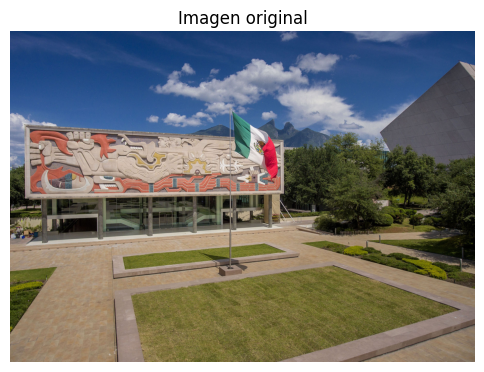

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans

import requests
from io import BytesIO
url = "https://tec.mx/sites/default/files/repositorio/Campus/Monterrey/rectoria-campus-monterrey-tec.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Imagen original")
plt.show()


In [2]:

# 2. Preprocesar la imagen
img = np.array(image)   # Convertir a numpy
print("Rango de valores de los pixeles:", img.min(), "-", img.max())
print("Forma de la matriz de pixeles:", img.shape)
img_aplanada = img.reshape(-1, 3) / 255.0  # Normalizar a [0, 1]
print("Forma aplanada:", img_aplanada.shape)


Rango de valores de los pixeles: 0 - 255
Forma de la matriz de pixeles: (1365, 1920, 3)
Forma aplanada: (2620800, 3)


In [3]:
# Closterizando con 16 colores
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)          
kmeans.fit(img_aplanada)
labels = kmeans.labels_
print(labels.shape)

for label, count in zip(*np.unique(labels, return_counts=True)):
    print(f"Color {label}: {count} pixeles")


(2620800,)
Color 0: 1563859 pixeles
Color 1: 1056941 pixeles


In [4]:
centroids = kmeans.cluster_centers_
print("Centroides: ")
for i, c in enumerate(centroids):
    print(f"Color {i}: {c}")

Centroides: 
Color 0: [0.25455881 0.29863764 0.30398808]
Color 1: [0.63809235 0.57285586 0.51787528]


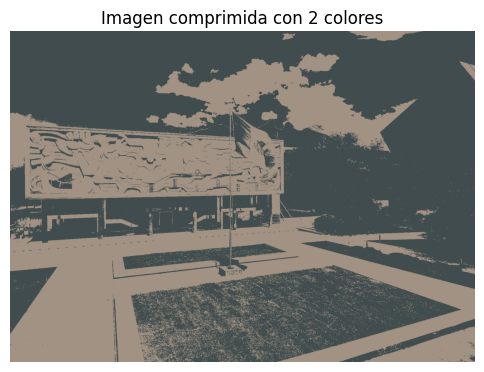

In [5]:
compressed_img = kmeans.cluster_centers_[labels]
compressed_img = (compressed_img.reshape(np.array(img).shape) * 255).astype(np.uint8)


# type(compressed_img)
# print(compressed_img.shape)
# # histogramas de colores
# plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
# plt.hist(img_aplanada, bins=50, color=['r', 'g', 'b'], alpha=0.7)
# plt.title("Histograma de colores - Imagen original")        
# plt.subplot(1, 2, 2)
# plt.hist(compressed_img.reshape(-1, 3) / 255.0, bins=50, color=['r', 'g', 'b'], alpha=0.7)
# plt.title(f"Histograma de colores - Imagen comprimida con {k} colores")
# plt.show()


# Mostrar imagen comprimida
plt.figure(figsize=(6, 6))
plt.imshow(compressed_img)
plt.axis("off")
plt.title(f"Imagen comprimida con {k} colores")
plt.show()


# DBSCAN

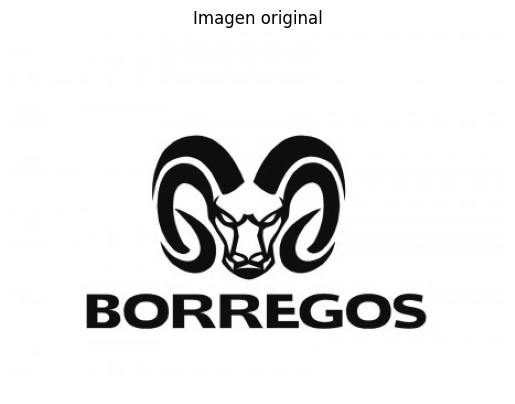

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from PIL import Image
import requests
from io import BytesIO

# Cargamos imagen desde URL
url = "https://fd75fff763.cbaul-cdnwnd.com/175c318d66fe13f1d20d6b1e98cab39c/system_preview_detail_200000047-df5ace0543/BORRERGO.jpg"
#url = "https://brandemia.org/sites/default/files/sites/default/files/logotipo_tecnologico_monterrey_version_circular.jpg"  # ejemplo simple
#url = "https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/072014/borregos_salvajes_thumb_0.jpg?itok=vk1CWmmo"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("L")  # Cambiar a escala de grises


plt.imshow(image, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()



#### Binarizamos la imágen

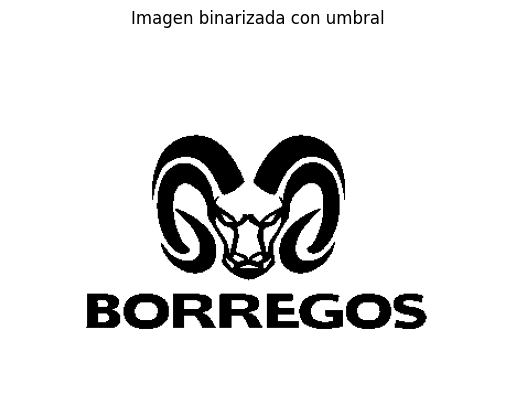

In [7]:
arr = np.array(image) 
filas_coords, cols_coords = np.where(arr < 180)  
coords = np.column_stack([filas_coords, cols_coords])  

arr_umbral = (arr < 180).astype(int)
plt.imshow(arr_umbral, cmap="gray_r") 
plt.title("Imagen binarizada con umbral")
plt.axis("off")
plt.show()


Aplicamos DBSCAN

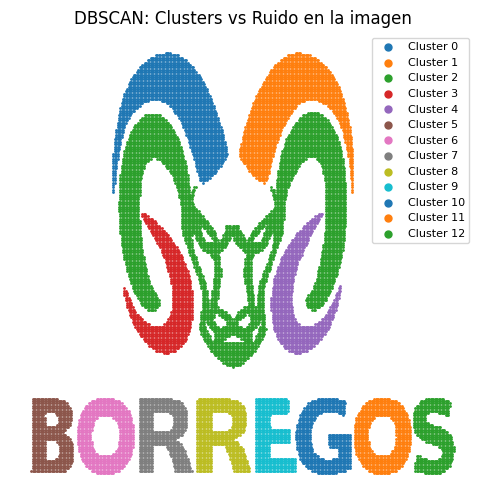

In [8]:
db = DBSCAN(eps=2, min_samples=5).fit(coords)
labels = db.labels_

plt.figure(figsize=(6, 6))
unique_labels = set(labels)

for lbl in unique_labels:
    mask = labels == lbl
    if lbl == -1:
        plt.scatter(coords[mask, 1], -coords[mask, 0], s=1, c="black", label="Ruido")
    else:
        plt.scatter(coords[mask, 1], -coords[mask, 0], s=1, label=f"Cluster {lbl}")

plt.title("DBSCAN: Clusters vs Ruido en la imagen")
plt.axis("off")
plt.legend(markerscale=5, fontsize=8)
plt.show()

Compara con Kmeans

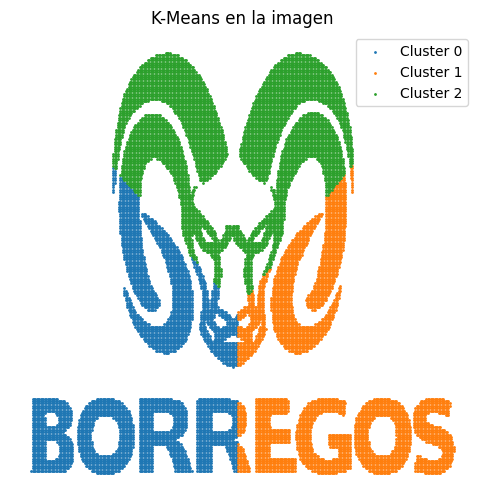

In [9]:
from sklearn.cluster import KMeans

# Aplicar K-Means con 3 clusters (prueba distintos k)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(coords)
labels_kmeans = kmeans.labels_

# Visualizar resultados
plt.figure(figsize=(6, 6))
for lbl in np.unique(labels_kmeans):
    mask = labels_kmeans == lbl
    plt.scatter(coords[mask, 1], -coords[mask, 0], s=1, label=f"Cluster {lbl}")

plt.title("K-Means en la imagen")
plt.axis("off")
plt.legend()
plt.show()

Agrupamiento Jerárquico

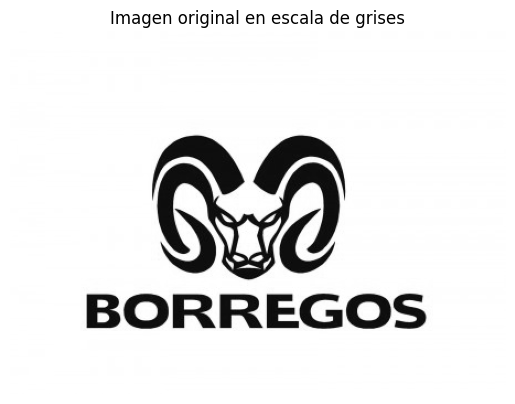

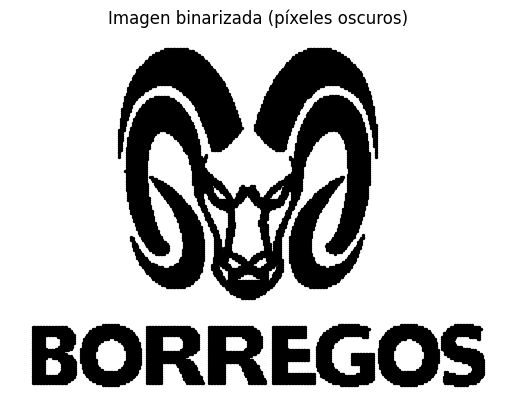

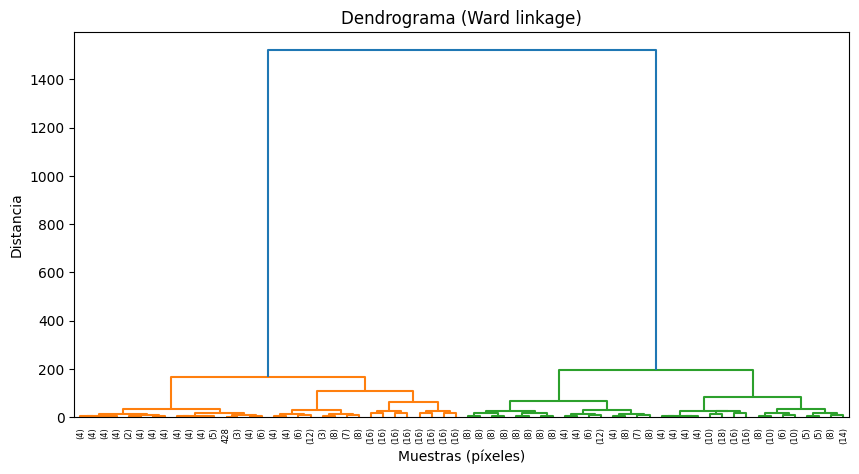

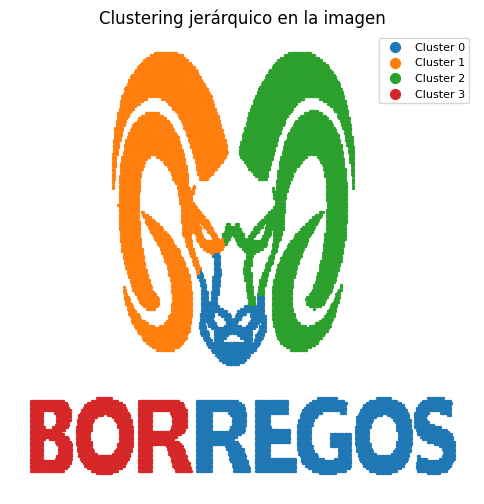

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


url = "https://fd75fff763.cbaul-cdnwnd.com/175c318d66fe13f1d20d6b1e98cab39c/system_preview_detail_200000047-df5ace0543/BORRERGO.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("L")
#image = image.resize((80, 80)) 
plt.imshow(image, cmap="gray")
plt.title("Imagen original en escala de grises")
plt.axis("off")
plt.show()

arr = np.array(image)
coords = np.column_stack(np.where(arr < 150))  # píxeles oscuros

plt.scatter(coords[:, 1], -coords[:, 0], s=2, c="black")
plt.title("Imagen binarizada (píxeles oscuros)")
plt.axis("off")
plt.show()


Z = linkage(coords[:500], method='ward')  

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrograma (Ward linkage)")
plt.xlabel("Muestras (píxeles)")
plt.ylabel("Distancia")
plt.show()


clusterer = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels = clusterer.fit_predict(coords)

plt.figure(figsize=(6, 6))
for lbl in np.unique(labels):
    mask = labels == lbl
    plt.scatter(coords[mask, 1], -coords[mask, 0], s=2, label=f"Cluster {lbl}")

plt.title("Clustering jerárquico en la imagen")
plt.axis("off")
plt.legend(markerscale=5, fontsize=8)
plt.show()


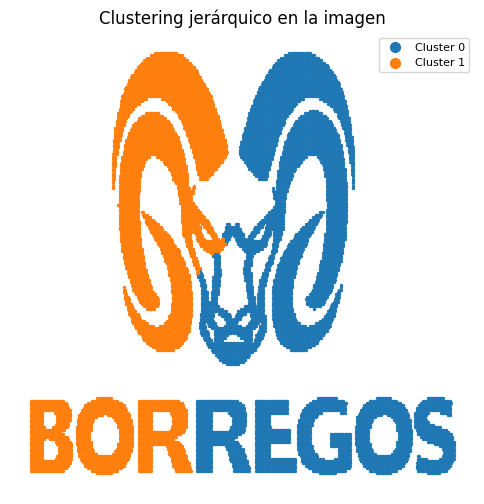

In [11]:

clusterer = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels = clusterer.fit_predict(coords)

plt.figure(figsize=(6, 6))
for lbl in np.unique(labels):
    mask = labels == lbl
    plt.scatter(coords[mask, 1], -coords[mask, 0], s=2, label=f"Cluster {lbl}")

plt.title("Clustering jerárquico en la imagen")
plt.axis("off")
plt.legend(markerscale=5, fontsize=8)
plt.show()

#### Usando agrupamiento jerarquico

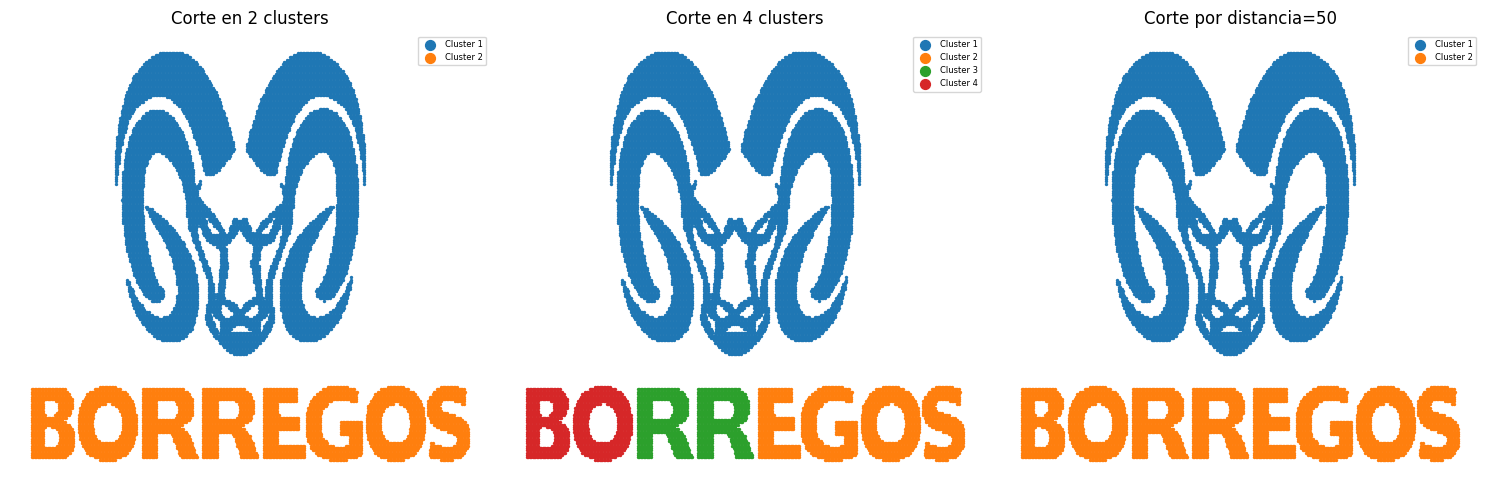

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster


Z = linkage(coords, method="single")  


labels_2 = fcluster(Z, t=2, criterion="maxclust")       # 2 clusters
labels_4 = fcluster(Z, t=4, criterion="maxclust")       # 4 clusters
labels_dist = fcluster(Z, t=10, criterion="distance")   # corte por distancia=10

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, labels, title in zip(
    axes,
    [labels_2, labels_4, labels_dist],
    ["Corte en 2 clusters", "Corte en 4 clusters", "Corte por distancia=50"]
):
    for lbl in np.unique(labels):
        mask = labels == lbl
        ax.scatter(coords[mask, 1], -coords[mask, 0], s=2, label=f"Cluster {lbl}")
    ax.set_title(title)
    ax.axis("off")
    ax.legend(markerscale=5, fontsize=6)

plt.tight_layout()
plt.show()

#### Agrupamiento jerárquico de las Capitales de los Estados

In [16]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from scipy.cluster.hierarchy import linkage, fcluster
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors


# Dataset
X = df[["lat", "lon"]].values
D = pdist(df[["lat","lon"]].values, lambda u,v: haversine(u,v))
Z = linkage(D, method="average")  
 
def plot_clusters(n_clusters=4):
    labels = fcluster(Z, t=n_clusters, criterion="maxclust")

    def distinct_colors(n):
        return [mcolors.hsv_to_rgb((i/n, 0.9, 0.9)) for i in range(n)]

    colors = distinct_colors(n_clusters)

    plt.figure(figsize=(15, 15))
    plt.scatter(df["lon"], df["lat"], c=[colors[l-1] for l in labels], s=100, edgecolors="black")


    for i, row in df.iterrows():
        plt.text(row["lon"] + 0.3, row["lat"], row["capital"], fontsize=8)

    plt.title(f"Capitales mexicanas agrupadas en {n_clusters} clusters")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.xlim(-118, -86)
    plt.ylim(14, 33)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(alpha=0.3, ls="--")
    plt.show()


interact(plot_clusters, n_clusters=IntSlider(min=1, max=32, step=1, value=4));

NameError: name 'pdist' is not defined

interactive(children=(IntSlider(value=4, description='n_clusters', max=32, min=1), Output()), _dom_classes=('w…

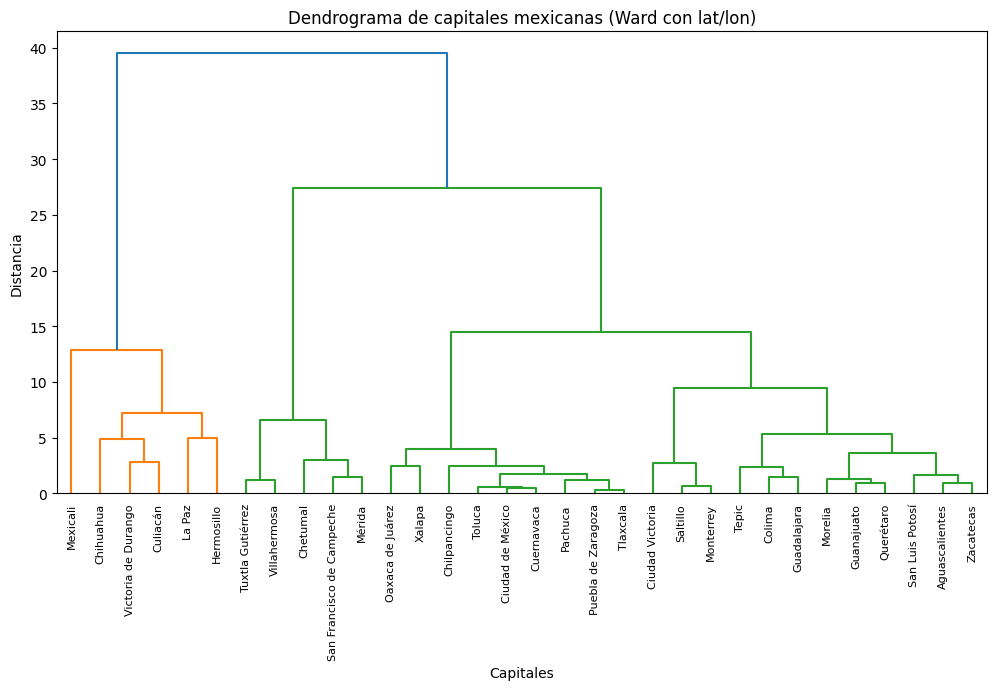

                estado                    capital  cluster
0       Aguascalientes             Aguascalientes        4
1      Baja California                   Mexicali        1
2  Baja California Sur                     La Paz        1
3             Campeche  San Francisco de Campeche        2
4             Coahuila                   Saltillo        4


In [14]:
# Librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from ipywidgets import interact, IntSlider
import matplotlib.colors as mcolors

# -----------------------------
# Dataset: capitales mexicanas con coordenadas en lat/lon (WGS84)
capitales_mexico_latlon = [
    {"estado": "Aguascalientes", "capital": "Aguascalientes", "lat": 21.8853, "lon": -102.2916},
    {"estado": "Baja California", "capital": "Mexicali", "lat": 32.6519, "lon": -115.4683},
    {"estado": "Baja California Sur", "capital": "La Paz", "lat": 24.1426, "lon": -110.3128},
    {"estado": "Campeche", "capital": "San Francisco de Campeche", "lat": 19.8301, "lon": -90.5349},
    {"estado": "Coahuila", "capital": "Saltillo", "lat": 25.4389, "lon": -100.9730},
    {"estado": "Colima", "capital": "Colima", "lat": 19.2433, "lon": -103.7250},
    {"estado": "Chiapas", "capital": "Tuxtla Gutiérrez", "lat": 16.7526, "lon": -93.1167},
    {"estado": "Chihuahua", "capital": "Chihuahua", "lat": 28.6320, "lon": -106.0691},
    {"estado": "Ciudad de México", "capital": "Ciudad de México", "lat": 19.4326, "lon": -99.1332},
    {"estado": "Durango", "capital": "Victoria de Durango", "lat": 24.0220, "lon": -104.6540},
    {"estado": "Guanajuato", "capital": "Guanajuato", "lat": 21.0190, "lon": -101.2574},
    {"estado": "Guerrero", "capital": "Chilpancingo", "lat": 17.5516, "lon": -99.5007},
    {"estado": "Hidalgo", "capital": "Pachuca", "lat": 20.1230, "lon": -98.7346},
    {"estado": "Jalisco", "capital": "Guadalajara", "lat": 20.6597, "lon": -103.3496},
    {"estado": "México", "capital": "Toluca", "lat": 19.2922, "lon": -99.6532},
    {"estado": "Michoacán", "capital": "Morelia", "lat": 19.7008, "lon": -101.1844},
    {"estado": "Morelos", "capital": "Cuernavaca", "lat": 18.9261, "lon": -99.2308},
    {"estado": "Nayarit", "capital": "Tepic", "lat": 21.5085, "lon": -104.8957},
    {"estado": "Nuevo León", "capital": "Monterrey", "lat": 25.6866, "lon": -100.3161},
    {"estado": "Oaxaca", "capital": "Oaxaca de Juárez", "lat": 17.0732, "lon": -96.7266},
    {"estado": "Puebla", "capital": "Puebla de Zaragoza", "lat": 19.0413, "lon": -98.2062},
    {"estado": "Querétaro", "capital": "Querétaro", "lat": 20.5881, "lon": -100.3899},
    {"estado": "Quintana Roo", "capital": "Chetumal", "lat": 18.5001, "lon": -88.2961},
    {"estado": "San Luis Potosí", "capital": "San Luis Potosí", "lat": 22.1565, "lon": -100.9855},
    {"estado": "Sinaloa", "capital": "Culiacán", "lat": 24.8091, "lon": -107.3940},
    {"estado": "Sonora", "capital": "Hermosillo", "lat": 29.0729, "lon": -110.9559},
    {"estado": "Tabasco", "capital": "Villahermosa", "lat": 17.9869, "lon": -92.9303},
    {"estado": "Tamaulipas", "capital": "Ciudad Victoria", "lat": 23.7417, "lon": -99.1453},
    {"estado": "Tlaxcala", "capital": "Tlaxcala", "lat": 19.3139, "lon": -98.2413},
    {"estado": "Veracruz", "capital": "Xalapa", "lat": 19.5420, "lon": -96.9103},
    {"estado": "Yucatán", "capital": "Mérida", "lat": 20.9674, "lon": -89.5926},
    {"estado": "Zacatecas", "capital": "Zacatecas", "lat": 22.7709, "lon": -102.5833},
]

df = pd.DataFrame(capitales_mexico_latlon)

# -----------------------------
# Clustering con lat/lon
X = df[["lon", "lat"]].values
Z = linkage(X, method="ward")

def plot_clusters(n_clusters=4):
    labels = fcluster(Z, t=n_clusters, criterion="maxclust")

    def distinct_colors(n):
        return [mcolors.hsv_to_rgb((i/n, 0.9, 0.9)) for i in range(n)]

    colors = distinct_colors(n_clusters)

    plt.figure(figsize=(10, 8))
    plt.scatter(df["lon"], df["lat"],
                c=[colors[l-1] for l in labels],
                s=100, edgecolors="black")

    for _, row in df.iterrows():
        plt.text(row["lon"] + 0.2, row["lat"], row["capital"], fontsize=8)

    plt.title(f"Capitales mexicanas agrupadas en {n_clusters} clusters (lat/lon)")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.grid(alpha=0.3, ls="--")
    plt.show()

interact(plot_clusters, n_clusters=IntSlider(min=1, max=32, step=1, value=4));

# -----------------------------
# Dendrograma
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df["capital"].values, leaf_rotation=90)
plt.title("Dendrograma de capitales mexicanas (Ward con lat/lon)")
plt.xlabel("Capitales")
plt.ylabel("Distancia")
plt.show()

# -----------------------------
# Etiquetas finales de clusters
labels = fcluster(Z, t=4, criterion="maxclust")
df["cluster"] = labels

print(df[["estado", "capital", "cluster"]].head())


interactive(children=(IntSlider(value=4, description='n_clusters', max=32, min=1), Output()), _dom_classes=('w…

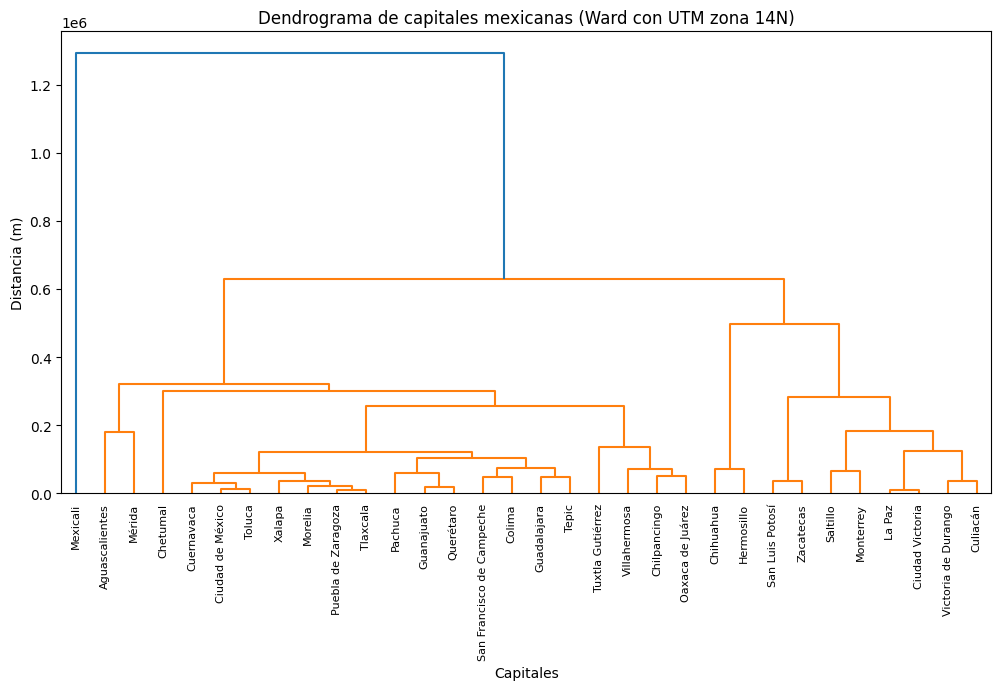

                estado                    capital  cluster
0       Aguascalientes             Aguascalientes        1
1      Baja California                   Mexicali        4
2  Baja California Sur                     La Paz        3
3             Campeche  San Francisco de Campeche        1
4             Coahuila                   Saltillo        3


In [15]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# DataFrame
capitales_mexico_utm = [
    {"estado": "Aguascalientes", "capital": "Aguascalientes", "x": 774405, "y": 2420235},
    {"estado": "Baja California", "capital": "Mexicali", "x": 677640, "y": 3610760},
    {"estado": "Baja California Sur", "capital": "La Paz", "x": 552462, "y": 2672256},
    {"estado": "Campeche", "capital": "San Francisco de Campeche", "x": 636008, "y": 2192263},
    {"estado": "Coahuila", "capital": "Saltillo", "x": 442957, "y": 2798192},
    {"estado": "Colima", "capital": "Colima", "x": 590097, "y": 2179133},
    {"estado": "Chiapas", "capital": "Tuxtla Gutiérrez", "x": 448133, "y": 1852605},
    {"estado": "Chihuahua", "capital": "Chihuahua", "x": 388047, "y": 3168213},
    {"estado": "Ciudad de México", "capital": "Ciudad de México", "x": 488731, "y": 2150276},
    {"estado": "Durango", "capital": "Victoria de Durango", "x": 444587, "y": 2659459},
    {"estado": "Guanajuato", "capital": "Guanajuato", "x": 514159, "y": 2272697},
    {"estado": "Guerrero", "capital": "Chilpancingo", "x": 496100, "y": 1941844},
    {"estado": "Hidalgo", "capital": "Pachuca", "x": 514319, "y": 2208309},
    {"estado": "Jalisco", "capital": "Guadalajara", "x": 593113, "y": 2227760},
    {"estado": "México", "capital": "Toluca", "x": 478657, "y": 2143208},
    {"estado": "Michoacán", "capital": "Morelia", "x": 543053, "y": 2143561},
    {"estado": "Morelos", "capital": "Cuernavaca", "x": 488657, "y": 2115795},
    {"estado": "Nayarit", "capital": "Tepic", "x": 572123, "y": 2272317},
    {"estado": "Nuevo León", "capital": "Monterrey", "x": 448623, "y": 2862975},
    {"estado": "Oaxaca", "capital": "Oaxaca de Juárez", "x": 514765, "y": 1990849},
    {"estado": "Puebla", "capital": "Puebla de Zaragoza", "x": 527083, "y": 2121711},
    {"estado": "Querétaro", "capital": "Querétaro", "x": 499302, "y": 2260988},
    {"estado": "Quintana Roo", "capital": "Chetumal", "x": 763282, "y": 1970976},
    {"estado": "San Luis Potosí", "capital": "San Luis Potosí", "x": 511922, "y": 2439737},
    {"estado": "Sinaloa", "capital": "Culiacán", "x": 409762, "y": 2645439},
    {"estado": "Sonora", "capital": "Hermosillo", "x": 360819, "y": 3101918},
    {"estado": "Tabasco", "capital": "Villahermosa", "x": 570284, "y": 1947523},
    {"estado": "Tamaulipas", "capital": "Ciudad Victoria", "x": 546930, "y": 2680242},
    {"estado": "Tlaxcala", "capital": "Tlaxcala", "x": 533068, "y": 2131611},
    {"estado": "Veracruz", "capital": "Xalapa", "x": 570812, "y": 2128894},
    {"estado": "Yucatán", "capital": "Mérida", "x": 735901, "y": 2245437},
    {"estado": "Zacatecas", "capital": "Zacatecas", "x": 476217, "y": 2449461},
]

df_utm = pd.DataFrame(capitales_mexico_utm)


X = df_utm[["x", "y"]].values
Z = linkage(X, method="average")

def plot_clusters(n_clusters=4):
    labels = fcluster(Z, t=n_clusters, criterion="maxclust")

    def distinct_colors(n):
        return [mcolors.hsv_to_rgb((i/n, 0.9, 0.9)) for i in range(n)]

    colors = distinct_colors(n_clusters)

    plt.figure(figsize=(15, 15))
    plt.scatter(df["lon"], df["lat"], c=[colors[l-1] for l in labels], s=100, edgecolors="black")


    for i, row in df.iterrows():
        plt.text(row["lon"] + 0.3, row["lat"], row["capital"], fontsize=8)

    plt.title(f"Capitales mexicanas agrupadas en {n_clusters} clusters")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.xlim(-118, -86)
    plt.ylim(14, 33)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(alpha=0.3, ls="--")
    plt.show()


interact(plot_clusters, n_clusters=IntSlider(min=1, max=32, step=1, value=4));

# Dendrograma
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df_utm["capital"].values, leaf_rotation=90)
plt.title("Dendrograma de capitales mexicanas (Ward con UTM zona 14N)")
plt.xlabel("Capitales")
plt.ylabel("Distancia (m)")
plt.show()

# Cortar en clusters
labels = fcluster(Z, t=4, criterion="maxclust")
df_utm["cluster"] = labels

print(df_utm[["estado", "capital", "cluster"]].head())

Colores Autoorganizados



In [17]:
#!pip install minisom

import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom

# 1. Generar datos RGB
data = np.random.randint(0, 256, (200, 3)) / 255.0  # 200 colores aleatorios

# 2. Crear el SOM
som = MiniSom(x=20, y=20, input_len=3, sigma=1.0, learning_rate=0.5)
som.random_weights_init(data)
som.train_random(data, 1000)  # entrenar con 1000 iteraciones

# 3. Visualizar el mapa de colores
weights = som.get_weights()
plt.imshow(weights)
plt.title("Mapa Autoorganizado de Colores RGB")
plt.axis("off")
plt.show()


ModuleNotFoundError: No module named 'minisom'